<a href="https://colab.research.google.com/github/JACKARPANJACK/AI-Lab-6th-sem/blob/main/Bi_Directional_BFS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install matplotlib
!pip install networkx

BFS Path: [0, 4, 6, 7, 8, 10, 14]
DFS Path: [0, 4, 6, 7, 8, 10, 14]
Bi-Directional BFS Path: [0, 4, 6, 7, 8, 10, 14]
Bi-Directional DFS Path: [0, 4, 6, 7, 8, 10, 14]


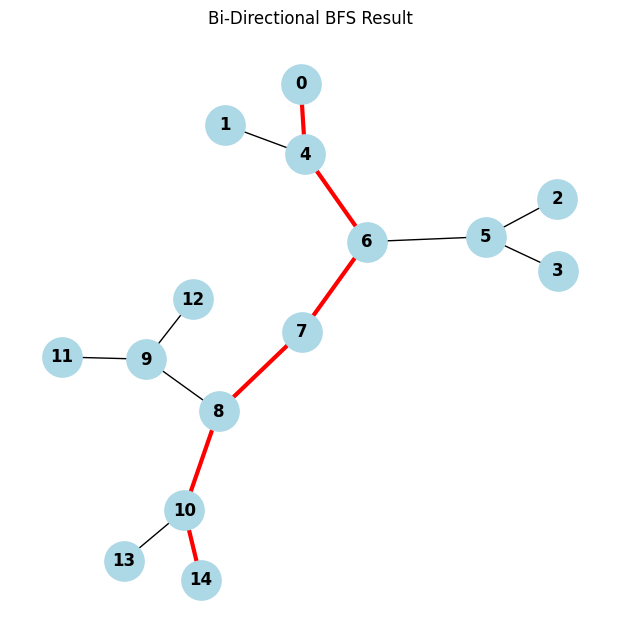

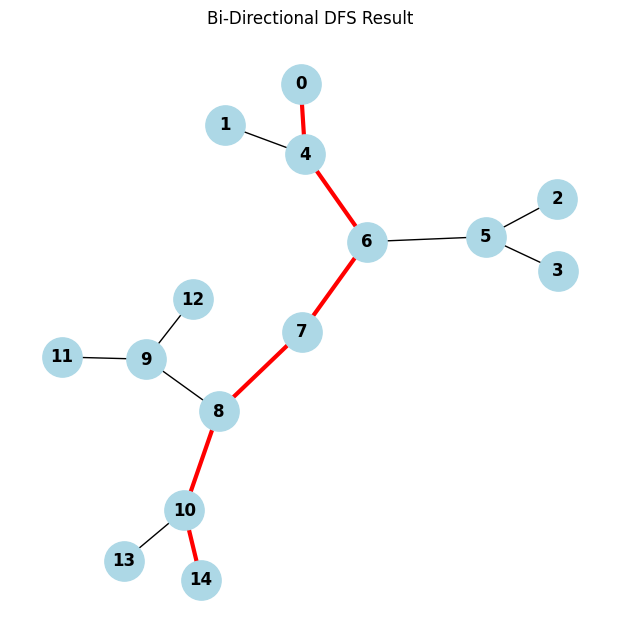

In [ ]:
from collections import deque
import networkx as nx
import matplotlib.pyplot as plt

def reconstruct_path_single(end, visited):
    path = []
    while end is not None:
        path.append(end)
        end = visited[end]
    return path[::-1]


def reconstruct_path_bidirectional(meet, front_visited, back_visited):
    path = []
    node = meet
    while node is not None:
        path.append(node)
        node = front_visited[node]
    path.reverse()

    # Meeting node → goal
    node = back_visited[meet]
    while node is not None:
        path.append(node)
        node = back_visited[node]

    return path

def bfs(graph, start, goal):
    queue = deque([start])
    visited = {start: None}

    while queue:
        current = queue.popleft()

        if current == goal:
            return reconstruct_path_single(current, visited)

        for neighbor in graph.get(current, []):
            if neighbor not in visited:
                visited[neighbor] = current
                queue.append(neighbor)

    return None

def dfs(graph, start, goal):
    stack = [start]
    visited = {start: None}

    while stack:
        current = stack.pop()

        if current == goal:
            return reconstruct_path_single(current, visited)

        for neighbor in graph.get(current, []):
            if neighbor not in visited:
                visited[neighbor] = current
                stack.append(neighbor)

    return None

def bidirectional_dfs(graph, start, goal):
    if start == goal:
        return [start]

    front_stack = [start]
    back_stack = [goal]
    front_visited = {start: None}
    back_visited = {goal: None}

    while front_stack and back_stack:
        current_front = front_stack.pop()
        for neighbor in graph.get(current_front, []):
            if neighbor not in front_visited:
                front_visited[neighbor] = current_front
                front_stack.append(neighbor)
                if neighbor in back_visited:
                    return reconstruct_path_bidirectional(
                        neighbor, front_visited, back_visited
                    )

        current_back = back_stack.pop()
        for neighbor in graph.get(current_back, []):
            if neighbor not in back_visited:
                back_visited[neighbor] = current_back
                back_stack.append(neighbor)
                if neighbor in front_visited:
                    return reconstruct_path_bidirectional(
                        neighbor, front_visited, back_visited
                    )

    return None


def bidirectional_bfs(graph, start, goal):
    if start == goal:
        return [start]

    front_queue = deque([start])
    back_queue = deque([goal])

    front_visited = {start: None}
    back_visited = {goal: None}

    while front_queue and back_queue:
        current = front_queue.popleft()
        for neighbor in graph.get(current, []):
            if neighbor not in front_visited:
                front_visited[neighbor] = current
                front_queue.append(neighbor)

                if neighbor in back_visited:
                    return reconstruct_path_bidirectional(
                        neighbor, front_visited, back_visited
                    )
        current = back_queue.popleft()
        for neighbor in graph.get(current, []):
            if neighbor not in back_visited:
                back_visited[neighbor] = current
                back_queue.append(neighbor)

                if neighbor in front_visited:
                    return reconstruct_path_bidirectional(
                        neighbor, front_visited, back_visited
                    )

    return None

def visualize_graph(graph, path=None, title="Graph Visualization"):
    G = nx.Graph()

    for node, neighbors in graph.items():
        for neighbor in neighbors:
            G.add_edge(node, neighbor)

    pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(6, 6))
    nx.draw(
        G, pos,
        with_labels=True,
        node_color="lightblue",
        node_size=800,
        font_weight="bold"
    )

    if path:
        edges = [(path[i], path[i + 1]) for i in range(len(path) - 1)]
        nx.draw_networkx_edges(
            G, pos,
            edgelist=edges,
            edge_color="red",
            width=3
        )

    plt.title(title)
    plt.show()

graph={
    0: [4],
    1: [4],
    4: [0, 1, 6],
    6: [4, 5, 7],
    5: [6, 2, 3],
    2: [5],
    3: [5],
    7: [6, 8],
    8: [7, 9, 10],
    9: [8, 11, 12],
    11: [9],
    12: [9],
    10: [8, 13, 14],
    13: [10],
    14: [10]
}

start, goal=0, 14
path_bfs = bfs(graph, start, goal)
path_dfs = dfs(graph, start, goal)
path_bidir = bidirectional_bfs(graph, start, goal)
path_bidir_dfs = bidirectional_dfs(graph, start, goal)
print("BFS Path:", path_bfs)
print("DFS Path:", path_dfs)
print("Bi-Directional BFS Path:", path_bidir)
print("Bi-Directional DFS Path:", path_bidir_dfs)
visualize_graph(graph, path_bidir, title="Bi-Directional BFS Result")
visualize_graph(graph, path_bidir_dfs, title="Bi-Directional DFS Result")